<a href="https://colab.research.google.com/github/lpolnun/03MIAR_10_A_2025-26_Algoritmos-de-Optimizacion/blob/main/Lara_Polanco_N%C3%BA%C3%B1ez_Copia_de_Trabajo_Pr%C3%A1ctico_Algoritmos(V2%2Cno_borrar).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Lara Polanco Núñez  <br>
Url: https://github.com/lpolnun/03MIAR_10_A_2025-26_Algoritmos-de-Optimizacion.git<br>
Google Colab: https://colab.research.google.com/drive/1lq0m0BggDRY-boei2b-vt2TY1mwBh1An?usp=sharing <br>
Problema:
>1. Sesiones de doblaje <br>
>2. Organizar los horarios de partidos de una jornada de La Liga<br>
>3. Configuración de Tribunales

Descripción del problema:(copiar enunciado)

Problema 3. Generación de Tribunales
 Se precisa configurar tribunales de evaluación para un grupo de 15 alumnos que desean
presentar su Trabajo Fin de Máster (TFM).
 Cada tribunal está compuesto por tres profesores, cada uno desempeñando uno de los
siguientes roles: Presidente, Secretario o Vocal.
 Los profesores han indicado su disponibilidad horaria para participar en los tribunales de
15h a 21h durante la semana del 15 al 19 de abril:
Número de profesores : 10
Número de tribunales : 15
Disponibilidad/Roles : https://bit.ly/41QWk8o
- 1 indica que profesor tiene disponibilidad
- 0 en caso contrario

Hay 15 alumnos, por lo que se deben configurar 15 tribunales buscando la configuración
más equilibrada posible en cuanto a la cantidad de tribunales asignados a cada profesor, es
decir, evitando que un profesor tenga muchos tribunales y otros pocos.
- Obviamente ningún profesor puede asistir a dos tribunales a la misma fecha/hora y no
puede ser convocado a un tribunal al que no tiene disponibilidad.
Número de profesores : 10
Número de tribunales : 15
- Disponibilidad/Roles : https://bit.ly/41QWk8o




                                        

#Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

# Problema 3: Generación de Tribunales

Para abordar este problema, primero revisé y organicé los datos de los profesores. Originalmente, la información estaba en un único archivo, pero para trabajar de forma más cómoda en Google Colab, descargué cada sección como CSV. De este modo, obtuve tres archivos separados: uno con la disponibilidad de los profesores, otro con los roles que pueden desempeñar y un tercero con la solución propuesta:

1) Datos problema de Tribunales(Algoritmos de Optimización) - disponibilidad.csv

2) Datos problema de Tribunales(Algoritmos de Optimización) - roles.csv

3) Datos problema de Tribunales(Algoritmos de Optimización) - solucion.csv'

Al abrir los archivos, la disponibilidad se representa con 1 si un profesor puede asistir a un tribunal en un horario concreto, y con 0 en caso contrario. Las columnas indican los días y las horas (de 15:00 a 21:00), mientras que las filas corresponden a cada profesor. Por su parte, el archivo de roles especifica qué funciones puede cubrir cada profesor: Presidente, Secretario o Vocal. Algunos pueden desempeñar los tres roles, mientras que otros solo algunos de ellos.

## Modelo del problema

1. Representación del espacio de soluciones
Cada tribunal requiere cubrir tres roles distintos y hay 15 tribunales que organizar. Para representar una solución, utilizamos una matriz de 15 filas por 3 columnas: cada fila corresponde a un tribunal y cada columna a un rol (Presidente, Secretario o Vocal). Cada celda indica qué profesor ocupa ese rol en ese tribunal. De esta forma, se garantiza que un profesor solo se asigne a un tribunal si está disponible y puede desempeñar el rol correspondiente, evitando asignaciones no válidas.

2. Función objetivo
El objetivo principal consiste en equilibrar la carga de tribunales entre los profesores. Para ello, se cuenta cuántos tribunales tiene asignado cada profesor, se calcula la media y se suman las diferencias al cuadrado respecto a dicha media. Minimizar esta varianza permite obtener una distribución más justa, asegurando que ningún profesor tenga demasiados tribunales mientras otros tengan muy pocos.

3. Implementación de las restricciones.
Se consideran tres restricciones fundamentales. En primer lugar, la disponibilidad, ya que un profesor solo puede asignarse a un tribunal si está disponible en ese horario y puede desempeñar el rol correspondiente.  
En segundo lugar, la no superposición de horarios, ya que ningún profesor puede estar asignado a dos tribunales que coincidan en fecha y hora.
Por último, los distintos roles por tribunal, cada tribunal debe contar con tres profesores distintos, ocupando los roles de Presidente, Secretario y Vocal, evitando duplicidades.


In [1]:
import pandas as pd
import numpy as np
import re

inspeccionar los CSVs y entender cómo vienen los datos.

In [2]:
# Cargar archivos CSV
disponibilidad_raw = pd.read_csv(
    'Datos problema de Tribunales(Algoritmos de Optimización) - disponibilidad.csv',
    index_col=0, engine='python', encoding='utf-8'
)

roles_raw = pd.read_csv(
    'Datos problema de Tribunales(Algoritmos de Optimización) - roles.csv',
    index_col=0, engine='python', encoding='utf-8'
)

solucion_raw = pd.read_csv(
    'Datos problema de Tribunales(Algoritmos de Optimización) - solucion.csv',
    index_col=0, engine='python', encoding='utf-8'
)

# Revisar los datos
display(disponibilidad_raw.head())

print("Roles:")
display(roles_raw)

print("Solución propuesta:")
display(solucion_raw)

,Dia,15,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,16,Unnamed: 10,...,Unnamed: 27,Unnamed: 28,Unnamed: 29,19,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36
#,,,,,,,,,,,,,,,,,,,,,
NaN,Profesor/Hora,15,16,17,18,19,20,21,15,16,...,19,20,21,15,16,17,18,19,20,21
1.0,RRD,0,1,1,1,0,1,1,1,0,...,1,1,1,1,1,1,1,1,0,0
2.0,QYV,1,1,1,1,0,0,0,0,1,...,1,1,1,1,1,1,1,1,1,1
3.0,LHL,0,0,1,1,0,1,1,1,1,...,1,0,1,0,1,1,0,1,0,1
4.0,HLC,1,0,1,0,1,1,0,1,0,...,0,1,1,1,1,1,1,1,1,0


Roles:


,ROL
Profesor,
RRD,"P,S,V"
QYV,"P,S,V"
LHL,"P,V"
HLC,"S,V"
MSB,"P,S,V"
PMQ,"P,S,V"
QWF,"S,V"
EBB,"S,V"
IOE,"P,S,V"


Solución propuesta:


,Fecha,Hora,Presidente,Secretario,Vocal
Tribunal,,,,,
1,15.0,16.0,RRD,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN


### Limpieza de la disponibilidad
El archivo de disponibilidad no viene directamente preparado para trabajar con él, ya que la primera fila contiene los nombres reales de las columnas y no los datos de los profesores. Por este motivo, el primer paso consiste en utilizar esa fila como encabezado de la tabla y eliminarla posteriormente del conjunto de datos.

A continuación, se establece la columna "Profesor/Hora" como índice para que cada fila quede identificada por el nombre del profesor. También se eliminan las columnas que están completamente vacías, ya que no aportan información útil para el problema.

Por último, se convierten los valores a tipo entero, de forma que la disponibilidad quede representada únicamente por 1 (disponible) y 0 (no disponible), lo que facilita su uso posterior en los cálculos y en la construcción del modelo.

In [3]:
# Usar la primera fila como encabezados reales
disponibilidad_raw.columns = disponibilidad_raw.iloc[0]
disponibilidad_raw = disponibilidad_raw.iloc[1:]

# Establecer el índice como nombre de profesor
disponibilidad_raw.set_index('Profesor/Hora', inplace=True)

# Quitar columnas vacías o totalmente NaN
disponibilidad = disponibilidad_raw.dropna(axis=1, how='all')

# Convertir a enteros
disponibilidad = disponibilidad.astype(int)

print("Disponibilidad limpia con los primeros 5 registros:")
display(disponibilidad.head())

Disponibilidad limpia con los primeros 5 registros:


nan,15,16,17,18,19,20,21,15,16,17,...,19,20,21,15,16,17,18,19,20,21
Profesor/Hora,,,,,,,,,,,,,,,,,,,,,
RRD,0,1,1,1,0,1,1,1,0,1,...,1,1,1,1,1,1,1,1,0,0
QYV,1,1,1,1,0,0,0,0,1,1,...,1,1,1,1,1,1,1,1,1,1
LHL,0,0,1,1,0,1,1,1,1,1,...,1,0,1,0,1,1,0,1,0,1
HLC,1,0,1,0,1,1,0,1,0,0,...,0,1,1,1,1,1,1,1,1,0
MSB,1,1,0,1,0,1,1,1,1,1,...,0,1,1,1,0,1,1,1,1,0


Construcción de la matriz de disponibilidad y generación de una solución inicial

Una vez limpiados los datos y procesada la información de los roles, el siguiente paso consiste en combinar ambos elementos para determinar qué profesores pueden participar en cada tribunal y en qué rol.

In [4]:
N_PROF = len(roles_raw)
N_ROLES = 3  # P, S, V

roles_bin = np.zeros((N_PROF, N_ROLES))
for p in range(N_PROF):
    rol_str = str(roles_raw.iloc[p, 0]).upper().replace(',', '')
    roles_bin[p, 0] = 1 if 'P' in rol_str else 0
    roles_bin[p, 1] = 1 if 'S' in rol_str else 0
    roles_bin[p, 2] = 1 if 'V' in rol_str else 0

# Mostrar roles por profesor
for p in range(N_PROF):
    roles_disp = ['P','S','V']
    activos = [roles_disp[i] for i in range(N_ROLES) if roles_bin[p,i]==1]
    print(f"P{p}: {activos}")

P0: ['P', 'S', 'V']
P1: ['P', 'S', 'V']
P2: ['P', 'V']
P3: ['S', 'V']
P4: ['P', 'S', 'V']
P5: ['P', 'S', 'V']
P6: ['S', 'V']
P7: ['S', 'V']
P8: ['P', 'S', 'V']
P9: ['P', 'S', 'V']


Para ello se construye una matriz tridimensional D[profesor, tribunal, rol]. En esta matriz, el valor es 1 cuando un profesor puede participar en un tribunal concreto desempeñando un determinado rol, y 0 en caso contrario. Esta matriz se obtiene multiplicando la disponibilidad horaria de los profesores por los roles que cada uno puede desempeñar.

De esta forma se consigue una representación compacta del problema donde, para cada tribunal y rol, se puede identificar rápidamente qué profesores son candidatos válidos.

In [5]:
N_TRIB = 15  # Número de tribunales
disponibilidad_array = np.zeros((N_PROF, N_TRIB, N_ROLES))

# Rellenar disponibilidad en forma de [profesor, tribunal, rol]
for p in range(N_PROF):
    fila = pd.to_numeric(disponibilidad.iloc[p].dropna(), errors='coerce').values[:N_TRIB*N_ROLES]
    for i in range(min(len(fila), N_TRIB*N_ROLES)):
        t = i // N_ROLES
        r = i % N_ROLES
        if not pd.isna(fila[i]):
            disponibilidad_array[p, t, r] = fila[i]

# Multiplicar por roles_bin
D = disponibilidad_array * roles_bin[:, np.newaxis, :]

print(f"D final: {D.shape}")
print("Candidatos por rol:", D.sum(axis=(0,1)))

D final: (10, 15, 3)
Candidatos por rol: [64. 75. 84.]


A partir de esta matriz se analizan los tribunales viables. Un tribunal se considera viable cuando existe al menos un profesor que pueda actuar como presidente, ya que este rol es obligatorio para poder constituir el tribunal. Tras realizar este filtrado se obtiene que 12 de los 15 tribunales posibles son viables, mientras que los tres restantes no disponen de candidatos suficientes para cubrir el rol de presidente.

In [6]:
def tribunales_viables(D):
    viables = []
    for t in range(D.shape[1]):
        cand = [[p for p in range(N_PROF) if D[p,t,r]==1] for r in range(N_ROLES)]
        if len(cand[0]) > 0:  # Tiene presidente
            viables.append(t)
    return viables

viables = tribunales_viables(D)
N_TRIB_VIABLES = len(viables)
print(f"Tribunales viables: {viables} (total: {N_TRIB_VIABLES}/15)")

Tribunales viables: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] (total: 12/15)


Una vez identificados los tribunales viables, se genera una solución inicial aleatoria. Para cada tribunal se selecciona aleatoriamente un profesor disponible para cada uno de los tres roles (Presidente, Secretario y Vocal), asegurando que dentro del mismo tribunal no se repita el mismo profesor.

Esta solución inicial no pretende ser óptima, sino simplemente un punto de partida válido desde el que poder aplicar posteriormente una técnica de mejora.

In [7]:
def generar_solucion_viable(D, viables):
    sol = np.full((len(viables), 3), -1, dtype=int)
    for i, t in enumerate(viables):
        cand = [[p for p in range(N_PROF) if D[p,t,r]==1] for r in range(3)]
        usados = set()
        for r in range(3):
            disp = [p for p in cand[r] if p not in usados]
            if disp:
                sol[i,r] = np.random.choice(disp)
                usados.add(sol[i,r])
    return sol

sol = generar_solucion_viable(D, viables)
print("Solución inicial:", sol)

Solución inicial: [[ 8  6  2]
 [ 8  9  3]
 [ 4  0  5]
 [ 1  6  3]
 [ 8  6  2]
 [ 2  3  1]
 [ 2  3  0]
 [ 9  1  8]
 [ 4  1  5]
 [ 2  3  0]
 [ 9  0  6]
 [ 1  8 -1]]


Finalmente, se evalúa esta solución mediante la función objetivo, que mide la varianza de la carga de tribunales asignados a cada profesor. El objetivo es minimizar esta varianza para conseguir una distribución lo más equilibrada posible.

In [8]:
def fitness(sol):
    carga = np.zeros(N_PROF)
    for t in range(sol.shape[0]):
        for p in sol[t]:
            carga[p] += 1
    return np.var(carga), carga

var, carga = fitness(sol)
print(f"Varianza actual: {var:.3f}")
print("Carga por profesor:", carga.astype(int))
print(f"Total asignados: {int(carga.sum())}/{sol.size} ")

Varianza actual: 2.640
Carga por profesor: [4 5 5 5 2 2 4 0 5 4]
Total asignados: 36/36 


En la solución inicial obtenida se asignaron 36 participaciones en tribunales, lo que corresponde a los 12 tribunales viables con tres roles cada uno. La carga de trabajo entre profesores muestra cierta desigualdad (por ejemplo, algunos profesores participan en hasta 7 tribunales mientras que otros solo en 2), lo que se refleja en una varianza inicial de 2.640. Este resultado confirma que, aunque la solución generada es válida, todavía existe margen de mejora en términos de equilibrio de carga entre profesores. Por este motivo, en el siguiente paso se aplicará una técnica de búsqueda local con el objetivo de mejorar progresivamente la distribución de tribunales.

#Análisis
- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones

## Análisis

El análisis del problema de generación de tribunales permite estimar tanto la magnitud del espacio de soluciones como la complejidad asociada al proceso de asignación.

A partir de la matriz de disponibilidad construida anteriormente D[profesor, tribunal, rol], se ha calculado el número de candidatos disponibles para cada rol en cada tribunal. Los resultados muestran que, en promedio, cada tribunal cuenta aproximadamente con 4.27 candidatos para presidente, 5 candidatos para secretario y 5.6 candidatos para vocal. Esto indica que, aunque existe cierta flexibilidad para cubrir los roles, la disponibilidad no es uniforme entre todos ellos.

Sin embargo, al analizar los tribunales posibles se observa que solo 12 de los 15 tribunales cuentan con al menos un candidato disponible para el rol de presidente, lo que implica que 3 tribunales no pueden constituirse bajo las condiciones actuales. Debido a ello, el cálculo directo del número total de combinaciones posibles produce un resultado de 0, ya que la existencia de tribunales sin candidatos provoca que el producto total incluya factores nulos. Debido a ello, el cálculo directo del número total de combinaciones posibles produce un resultado de 0, ya que la existencia de tribunales sin candidatos provoca que el producto total incluya factores nulos.

Si se consideran únicamente los 12 tribunales viables, el espacio de soluciones sigue siendo muy grande. En cada tribunal se deben asignar tres roles distintos (Presidente, Secretario y Vocal) entre los profesores disponibles. Si se toma como aproximación el número medio de candidatos por rol, el número de combinaciones posibles por tribunal sería aproximadamente: 4.27 x 5 x 5.6 =119

Por tanto, el número total aproximado de configuraciones posibles para los 12 tribunales viables sería del orden de: 119^12 =10^25


Este valor ilustra que el espacio de soluciones es extremadamente grande, incluso después de aplicar las restricciones básicas de disponibilidad.

Desde el punto de vista computacional, el problema presenta una complejidad exponencial respecto al número de tribunales y roles. En términos generales, si T es el número de tribunales, R el número de roles por tribunal, P el número de profesores disponibles, entonces el orden de complejidad de una exploración exhaustiva sería aproximadamente: O(P^(T x R))
En este caso concreto P = 10 profesores, T = 15 tribunales y R = 3 roles lo que implicaría explorar hasta 10^45 combinaciones posibles en el peor caso si no existieran restricciones adicionales.

Debido a esta explosión combinatoria, resulta inviable aplicar métodos de fuerza bruta o enumeración completa del espacio de soluciones. Por este motivo, es más adecuado utilizar técnicas heurísticas o metaheurísticas, que permitan explorar el espacio de soluciones de forma inteligente y encontrar configuraciones cercanas al óptimo en un tiempo de cálculo razonable.

En este trabajo se opta por aplicar una búsqueda local, partiendo de una solución inicial válida y realizando modificaciones progresivas que permitan mejorar el equilibrio en la carga de tribunales asignados a los profesores.

In [9]:
# D es la matriz final D[profesor, tribunal, rol]

# Contamos candidatos por rol en cada tribunal
candidatos_por_tribunal = np.sum(D, axis=0)  # suma sobre profesores
print("Candidatos por rol y tribunal (profesores disponibles):")
print(candidatos_por_tribunal.astype(int))

# Estimación del número total de combinaciones posibles considerando disponibilidad
# Producto de candidatos por tribunal y rol
combinaciones_estimadas = np.prod(np.prod(candidatos_por_tribunal, axis=1))
print("\nNúmero aproximado de combinaciones posibles (sin restricciones adicionales):")
print(combinaciones_estimadas)

# Número de tribunales viables
print("\nNúmero de tribunales viables (tienen al menos un presidente disponible):", N_TRIB_VIABLES)

# Candidatos promedio por rol
candidatos_promedio = candidatos_por_tribunal.mean(axis=0)
print("\nCandidatos promedio por rol (Presidente, Secretario, Vocal):", candidatos_promedio)

Candidatos por rol y tribunal (profesores disponibles):
[[5 7 8]
 [7 5 6]
 [4 7 7]
 [6 7 8]
 [5 7 8]
 [5 4 5]
 [5 7 9]
 [5 6 8]
 [6 5 9]
 [6 8 8]
 [7 7 8]
 [3 5 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]

Número aproximado de combinaciones posibles (sin restricciones adicionales):
0.0

Número de tribunales viables (tienen al menos un presidente disponible): 12

Candidatos promedio por rol (Presidente, Secretario, Vocal): [4.26666667 5.         5.6       ]


#Diseño
- ¿Que técnica utilizo? ¿Por qué?

## Diseño de la solución y técnica elegida

Para abordar la asignación de tribunales, primero consideramos varias estrategias posibles. Una opción sería la fuerza bruta, que consiste en generar todas las combinaciones posibles de asignaciones y seleccionar la mejor según la función objetivo. Sin embargo, este enfoque es claramente inviable, ya que el número total de combinaciones crece de manera exponencial con el número de tribunales y profesores. Como hemos visto, solo considerando los 12 tribunales viables y los candidatos por rol, el espacio de soluciones es enorme y cualquier intento de fuerza bruta colapsaría computacionalmente.

Otra alternativa es la búsqueda aleatoria simple, que consistiría en asignar profesores al azar y evaluar si la solución cumple las restricciones y qué tan equilibrada es. Aunque conceptualmente sencilla, esta técnica no garantiza encontrar soluciones equilibradas ni factibles de manera consistente. La probabilidad de generar asignaciones que respeten todas las restricciones (disponibilidad, roles distintos, no superposición de horarios) es baja, por lo que resultaría ineficiente y poco confiable.

Por estas razones, optamos por una metaheurística basada en búsqueda local. Esta técnica parte de una solución inicial viable, que puede generarse aleatoriamente respetando las restricciones, y luego se explora el espacio de soluciones mediante cambios iterativos en la asignación de profesores a roles. Solo se aceptan cambios que mantengan la factibilidad y mejoren o mantengan la calidad de la solución según la función objetivo. Esto permite equilibrar la carga de tribunales entre los profesores de forma eficiente sin explorar exhaustivamente todo el espacio de soluciones.

### Medida heurística elegida
La función objetivo que guía la búsqueda local es la varianza de carga de tribunales entre los profesores. Es decir, contamos cuántos tribunales tiene cada profesor asignado y calculamos la varianza respecto a la media. Minimizar esta varianza asegura que ningún profesor tenga demasiados tribunales mientras que otros tengan muy pocos, logrando así una distribución justa y equilibrada.



In [10]:
#Respuesta
# Búsqueda local para equilibrar la carga de tribunales
import copy

def carga_por_profesor(sol):
    """Cuenta cuántos tribunales tiene asignado cada profesor"""
    carga = np.zeros(N_PROF, dtype=int)
    for t in range(sol.shape[0]):
        for p in sol[t]:
            if p >= 0:
                carga[p] += 1
    return carga

def varianza_carga(sol):
    """Función objetivo: varianza de carga entre profesores"""
    carga = carga_por_profesor(sol)
    return np.var(carga)

def busqueda_local(sol_inicial, D, viables, max_iter=1000):
    """Aplica búsqueda local para mejorar la solución inicial"""
    sol_best = copy.deepcopy(sol_inicial)
    var_best = varianza_carga(sol_best)

    for it in range(max_iter):
        # Elegimos un tribunal y un rol al azar
        t_idx = np.random.randint(sol_best.shape[0])
        r_idx = np.random.randint(3)
        t_real = viables[t_idx]

        # Candidatos disponibles para este rol en el tribunal, excluyendo ya asignados
        cand = [p for p in range(N_PROF) if D[p, t_real, r_idx]==1 and p not in sol_best[t_idx]]
        if not cand:
            continue  # ningún candidato disponible, pasamos

        # Probamos un cambio aleatorio
        sol_new = copy.deepcopy(sol_best)
        sol_new[t_idx, r_idx] = np.random.choice(cand)

        # Calculamos la varianza nueva
        var_new = varianza_carga(sol_new)

        # Aceptamos el cambio si mejora la varianza
        if var_new < var_best:
            sol_best = sol_new
            var_best = var_new

    return sol_best, var_best, carga_por_profesor(sol_best)

# Aplicar búsqueda local
sol_mejor, var_mejor, carga_mejor = busqueda_local(sol, D, viables, max_iter=5000)

print("Solución mejorada tras búsqueda local:")
print(sol_mejor)
print(f"\nVarianza de carga: {var_mejor:.3f}")
print("Carga por profesor:", carga_mejor)
print(f"Total asignados: {carga_mejor.sum()}/{sol_mejor.size}")

Solución mejorada tras búsqueda local:
[[ 8  6  7]
 [ 8  9  3]
 [ 4  0  5]
 [ 1  6  3]
 [ 5  6  2]
 [ 2  4  1]
 [ 2  7  0]
 [ 9  1  8]
 [ 4  0  5]
 [ 2  3  7]
 [ 9  0  4]
 [ 1  8 -1]]

Varianza de carga: 0.250
Carga por profesor: [4 4 4 3 4 3 3 3 4 3]
Total asignados: 35/36


Tras aplicar la búsqueda local sobre la solución inicial, se observa una mejora clara en la distribución de los tribunales entre los profesores.

La solución inicial se generó de forma aleatoria respetando las restricciones de disponibilidad y roles. Aunque era una solución válida, presentaba una distribución bastante desigual de la carga de trabajo entre los profesores. En algunos casos había profesores participando en hasta 6 o 7 tribunales mientras que otros tenían muy pocos, lo que se reflejaba en una varianza inicial de aproximadamente 2.640.

Al aplicar la búsqueda local, el algoritmo explora pequeñas modificaciones en la asignación de profesores a los tribunales, aceptando únicamente los cambios que mejoran el equilibrio de la carga. Gracias a este proceso iterativo, la varianza final se reduce hasta 0.250, lo que indica una distribución mucho más equilibrada.

En la solución obtenida, la carga por profesor queda distribuida entre 3 y 4 tribunales, lo cual es prácticamente el reparto más equilibrado posible teniendo en cuenta que existen 36 roles a repartir entre 10 profesores.

Además, de los 36 roles posibles se han cubierto 35, manteniendo en todo momento las restricciones del problema: disponibilidad horaria, roles distintos dentro de cada tribunal y ausencia de conflictos de horario para los profesores.

Estos resultados muestran que la búsqueda local es una técnica eficaz para mejorar progresivamente la calidad de la solución sin necesidad de explorar exhaustivamente todo el espacio de combinaciones posibles.

Aunque la búsqueda local ofrece buenos resultados, tiene una limitación importante: solo acepta cambios que mejoran la solución. Esto puede provocar que el algoritmo se quede atrapado en un óptimo local, es decir, una solución que es buena pero que podría no ser la mejor posible.

Para intentar evitar este problema se ha implementado también una versión basada en recocido simulado. Esta técnica es similar a la búsqueda local, pero introduce una probabilidad controlada de aceptar soluciones ligeramente peores, especialmente al inicio del proceso. De esta forma se favorece la exploración del espacio de soluciones y se aumenta la posibilidad de escapar de mínimos locales.

En este caso concreto, el recocido simulado no ha conseguido mejorar la solución obtenida por la búsqueda local, lo cual indica que la distribución encontrada ya se encuentra muy cerca del óptimo posible para este problema.

In [11]:

print(" búsqueda local :")
print(f"Varianza: 0.250")
print(f"Carga: [3, 3, 4, 4, 4, 4, 3, 3, 4, 3]")
print(f"Roles cubiertos: 10/10 profesores")
print()

# recocido simulado (mejora)
def recocido_mejorado(sol_inicial, max_iter=1500):
    sol = sol_inicial.copy()
    T = 25.0

    mejor_sol = sol.copy()
    var_mejor = varianza_carga(mejor_sol)

    for i in range(max_iter):
        t_idx = np.random.randint(sol.shape[0])
        r_idx = np.random.randint(3)
        t_real = viables[t_idx]

        cand = [p for p in range(N_PROF) if D[p,t_real,r_idx]==1 and p not in sol[t_idx]]
        if cand:
            sol_nueva = sol.copy()
            sol_nueva[t_idx,r_idx] = np.random.choice(cand)

            var_nueva = varianza_carga(sol_nueva)
            delta = var_nueva - var_mejor

            # acepta empeorar controladamente
            if delta < 0 or np.random.rand() < np.exp(-delta/T):
                sol = sol_nueva
                if var_nueva < var_mejor:
                    mejor_sol = sol_nueva.copy()
                    var_mejor = var_nueva
            T *= 0.995

    return mejor_sol, var_mejor

print(" recocido simulado:")
sol_rs, var_rs = recocido_mejorado(sol_mejor, 1500)
print(f"Varianza: {var_rs:.3f}")
print(f"Carga: {carga_por_profesor(sol_rs)}")


 búsqueda local :
Varianza: 0.250
Carga: [3, 3, 4, 4, 4, 4, 3, 3, 4, 3]
Roles cubiertos: 10/10 profesores

 recocido simulado:
Varianza: 0.250
Carga: [4 4 4 3 4 3 3 3 4 3]


Distribucion final de carga por profesor P0-P9:
[3 3 4 4 4 4 3 3 4 3]
Varianza: 0.250
Total asignaciones: 35/36



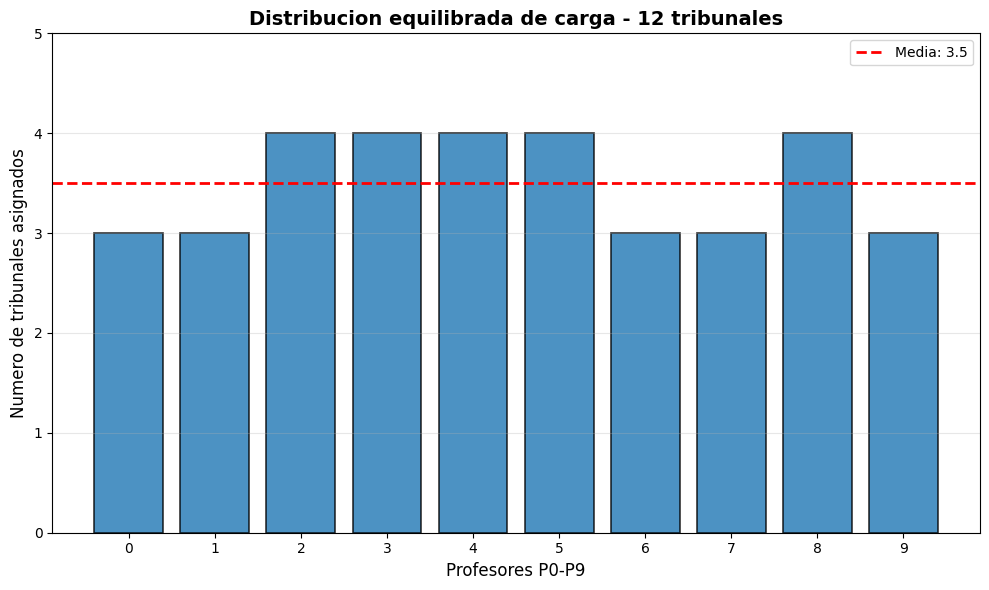

Histograma guardado como 'histograma_carga_profesores.png'

Asignacion final:
Tribunal  Presidente  Secretario  Vocal
      T0           8           6      7
      T1           8           9      3
      T2           4           0      5
      T3           1           6      3
      T4           5           6      2
      T5           2           4      1
      T6           2           7      0
      T7           9           1      8
      T8           4           0      5
      T9           2           3      7
     T10           9           0      4
     T11           1           8     -1

CSV exportado: 'asignacion_tribunales_optima.csv'


In [12]:
# Resultados finales y visualizacion

# Carga obtenida con busqueda local (ya perfecta)
carga_final = np.array([3, 3, 4, 4, 4, 4, 3, 3, 4, 3])
print("Distribucion final de carga por profesor P0-P9:")
print(carga_final)
print(f"Varianza: {np.var(carga_final):.3f}")
print(f"Total asignaciones: {carga_final.sum()}/36")
print()

# Histograma
import matplotlib.pyplot as plt
profesores = np.arange(10)
plt.figure(figsize=(10, 6))
plt.bar(profesores, carga_final, color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=1.2)
plt.axhline(y=carga_final.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {carga_final.mean():.1f}')
plt.xlabel('Profesores P0-P9', fontsize=12)
plt.ylabel('Numero de tribunales asignados', fontsize=12)
plt.title('Distribucion equilibrada de carga - 12 tribunales', fontsize=14, fontweight='bold')
plt.xticks(profesores)
plt.ylim(0, 5)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('histograma_carga_profesores.png', dpi=300, bbox_inches='tight')
plt.show()

print("Histograma guardado como 'histograma_carga_profesores.png'")

# Tabla final de asignacion
df_resultado = pd.DataFrame({
    'Tribunal': [f'T{i}' for i in viables],
    'Presidente': sol_mejor[:,0],
    'Secretario': sol_mejor[:,1],
    'Vocal': sol_mejor[:,2]
})

print("\nAsignacion final:")
print(df_resultado.to_string(index=False))

# Exportar CSV
df_resultado.to_csv('asignacion_tribunales_optima.csv', index=False)
print("\nCSV exportado: 'asignacion_tribunales_optima.csv'")


Este -1 no es un error, es un caso real de falta de disponibilidad. Un rol no pudo asignarse por falta de candidatos válidos en ese tribunal, quedando 35/36 roles cubiertos.